# Stain normalization: picking reference patch(es)

We want a **reference** patch (or a few) that:
- Have **enough tissue** so Macenko can estimate stain vectors (no degenerate matrix).
- Are **representative** (typical H&E, not pale/dark outliers).

**Approach:** Apply **stricter** quality filters; require **tissue % final ≥ 0.5**. Pick the reference **by computed parameters**: the patch closest to the median (tissue %, mean R, G, B) so it works as a generalizable "typical" reference for any H&E dataset. Fit Macenko and validate; optionally save reference index.

In [13]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)
print("Loaded train:", train_x.shape)

Loaded train: (262144, 96, 96, 3)


## 1. Quality helpers and metrics (same logic as tissue investigation)

We compute tissue % (saturation OR local variance, Otsu on edge cases), solid-color flag, and black ratio. For **reference candidates** we use a **stricter** minimum tissue: only patches with tissue % final **≥ 0.5** (exclude more than the 0.35 removal threshold).

In [14]:
def otsu_threshold_01(gray):
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    bin_centers = (np.arange(256) + 0.5) / 256.0
    total = hist.sum()
    if total == 0: return 0.5
    p = hist / total
    sigma_b_sq_max, best_t = -1.0, 0.5
    for t in range(1, 255):
        w0, w1 = p[:t].sum(), p[t:].sum()
        if w0 == 0 or w1 == 0: continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma_b_sq = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b_sq > sigma_b_sq_max:
            sigma_b_sq_max, best_t = sigma_b_sq, bin_centers[t]
    return best_t

def saturation_from_rgb(rgb):
    mx, mn = rgb.max(axis=2), rgb.min(axis=2)
    return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)

def local_variance_map(gray, win=11):
    m = uniform_filter(gray.astype(np.float64), size=win, mode='nearest')
    m2 = uniform_filter((gray.astype(np.float64))**2, size=win, mode='nearest')
    return m2 - m**2

def tissue_pct_otsu_normalized(gray):
    p5, p95 = np.percentile(gray, 5), np.percentile(gray, 95)
    span = max(p95 - p5, 1e-8)
    g = np.clip((gray - p5) / span, 0, 1)
    t = otsu_threshold_01(g)
    return float(np.sum(g < t) / g.size)

SAT_THRESHOLD = 0.12
VAR_THRESHOLD = 0.003
EDGE_LO, EDGE_HI = 0.12, 0.45
SOLID_COLOR_STD_THRESHOLD = 0.04
HIGH_BLACK_THRESHOLD = 0.5
# Stricter: only patches with plenty of tissue are reference candidates
REFERENCE_MIN_TISSUE = 0.5
LOCAL_VAR_WIN = 11

print("Reference candidates: tissue % final >= ", REFERENCE_MIN_TISSUE, ", not solid-color, not high black")

Reference candidates: tissue % final >=  0.5 , not solid-color, not high black


In [15]:
# Sample patches and compute metrics (same as tissue notebook)
n_sample = min(30000, len(train_x))
np.random.seed(42)
indices = np.random.choice(len(train_x), size=n_sample, replace=False)

rows = []
for i in indices:
    patch = np.asarray(train_x[i]).astype(np.float64)
    if patch.max() > 1.0: patch = patch / 255.0
    patch = np.clip(patch, 0, 1)
    gray = patch.mean(axis=2)
    n_px = gray.size
    n_elems = patch.size
    ratio_black = float(np.sum(patch <= 0.1) / n_elems)
    gray_std = float(np.std(gray))
    sat = saturation_from_rgb(patch)
    tissue_pct_sat = float(np.sum(sat > SAT_THRESHOLD) / n_px)
    var_map = local_variance_map(gray, win=LOCAL_VAR_WIN)
    tissue_pct_var = float(np.sum(var_map > VAR_THRESHOLD) / n_px)
    tissue_pct_combined = float(np.sum((sat > SAT_THRESHOLD) | (var_map > VAR_THRESHOLD)) / n_px)
    if EDGE_LO < tissue_pct_combined < EDGE_HI:
        otsu_norm = tissue_pct_otsu_normalized(gray)
        tissue_pct_final = max(tissue_pct_combined, otsu_norm)
    else:
        tissue_pct_final = tissue_pct_combined
    mean_rgb = patch.reshape(-1, 3).mean(axis=0)
    solid_color = 1 if gray_std < SOLID_COLOR_STD_THRESHOLD else 0
    blue_dom_pct = float((patch[:,:,2] > patch[:,:,0]).mean())  # B > R (for Macenko vs Reinhard rule)
    rows.append((i, ratio_black, gray_std, tissue_pct_final, solid_color, mean_rgb[0], mean_rgb[1], mean_rgb[2], blue_dom_pct))

data = np.array(rows)
idx_col = 0
b_col, std_col, tissue_col, solid_col = 1, 2, 3, 4
r_col, g_col, b_mean_col = 5, 6, 7
blue_dom_col = 8

solid_mask = data[:, solid_col] == 1
high_black_mask = data[:, b_col] >= HIGH_BLACK_THRESHOLD
high_tissue_mask = data[:, tissue_col] >= REFERENCE_MIN_TISSUE
candidate_mask = ~solid_mask & ~high_black_mask & high_tissue_mask
candidates = data[candidate_mask]

print("Sampled", n_sample, "patches")
print("Solid-color:", solid_mask.sum(), "| High black:", high_black_mask.sum(), "| Tissue >= ", REFERENCE_MIN_TISSUE, ":", high_tissue_mask.sum())
print("Reference candidates (not solid, not high black, tissue >= " + str(REFERENCE_MIN_TISSUE) + "):", len(candidates))

C:\Users\tamer\AppData\Local\Temp\ipykernel_14240\3842474581.py:21: RuntimeWarning: invalid value encountered in divide
  return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)


Sampled 30000 patches
Solid-color: 235 | High black: 3 | Tissue >=  0.5 : 27399
Reference candidates (not solid, not high black, tissue >= 0.5): 27376


## 2. Pick reference by computed parameters (best for any H&E dataset)

Among candidates, pick the patch **closest to the median** of (tissue %, mean R, mean G, mean B). The median is the most central/representative; no manual choice or dataset-specific percentile. This generalizes to any H&E dataset: the reference is always the "typical" patch in that set. Slight weight on R and B keeps the reference balanced (not too red or blue).

In [16]:
if len(candidates) == 0:
    raise RuntimeError("No reference candidates. Lower REFERENCE_MIN_TISSUE or increase n_sample.")

# Best-for-any-H&E-dataset: pick the patch closest to the *median* (tissue, R, G, B).
# The median is the most central/representative; no dataset-specific percentile bias.
med_tissue = np.median(candidates[:, tissue_col])
med_r = np.median(candidates[:, r_col])
med_g = np.median(candidates[:, g_col])
med_b = np.median(candidates[:, b_mean_col])
target = np.array([med_tissue, med_r, med_g, med_b])
feats = candidates[:, [tissue_col, r_col, g_col, b_mean_col]]
# Slight weight on R and B so we prefer a balanced H&E (not too red or blue)
weights = np.array([1.0, 1.5, 1.0, 1.5])  # [tissue, R, G, B]
dists = np.sum(weights * (feats - target) ** 2, axis=1)
best_idx_in_candidates = np.argmin(dists)
ref_train_idx = int(candidates[best_idx_in_candidates, idx_col])

print("Target (median tissue, R, G, B):", round(med_tissue, 3), round(med_r, 3), round(med_g, 3), round(med_b, 3))
print("Chosen reference (computed, no override): train index", ref_train_idx,
      "| tissue % =", round(candidates[best_idx_in_candidates, tissue_col], 3),
      "| mean R =", round(candidates[best_idx_in_candidates, r_col], 3), "| mean B =", round(candidates[best_idx_in_candidates, b_mean_col], 3))

Target (median tissue, R, G, B): 1.0 0.68 0.484 0.679
Chosen reference (computed, no override): train index 89340 | tissue % = 0.999 | mean R = 0.67 | mean B = 0.706


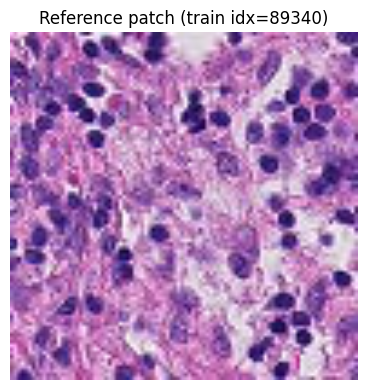

In [17]:
# Show reference patch
ref_patch = np.asarray(train_x[ref_train_idx])
if ref_patch.max() <= 1.0: ref_patch = np.clip(ref_patch, 0, 1)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(ref_patch, interpolation='bilinear')
ax.set_title(f"Reference patch (train idx={ref_train_idx})")
ax.axis("off")
plt.tight_layout()
plt.show()
# Note: PCam patches are 96x96; interpolation='bilinear' smooths the display. For 1:1 pixels use interpolation='nearest' and figsize=(2, 2).


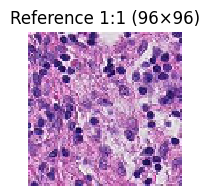

In [18]:
plt.figure(figsize=(2, 2))
plt.imshow(ref_patch, interpolation='nearest')
plt.axis('off')
plt.title('Reference 1:1 (96×96)')
plt.show()

## 3. Fit Macenko on reference and validate

Requires `staintools` and `spams` (use `pip install staintools spams-bin` on Windows). Restart the kernel after installing.

In [19]:
try:
    from staintools import StainNormalizer
    STAINTOOLS_AVAILABLE = True
except ImportError as e:
    STAINTOOLS_AVAILABLE = False
    print("StainTools import failed:", e)
    print('If the error is No module named "spams", run: pip install spams-bin (Windows)')
    print('Then restart the kernel and run this cell again.')

if STAINTOOLS_AVAILABLE:
    ref_uint8 = (np.clip(ref_patch, 0, 1) * 255).astype(np.uint8) if ref_patch.max() <= 1.0 else np.clip(ref_patch, 0, 255).astype(np.uint8)
    try:
        from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer
        ref_uint8 = LuminosityStandardizer.standardize(ref_uint8)
    except Exception as e_std:
        print("Luminosity standardizer skipped:", e_std)
    try:
        normalizer = StainNormalizer(method='macenko')
        normalizer.fit(ref_uint8)
        print("Macenko fitted successfully on reference patch.")
    except Exception as e:
        print("Macenko fit failed:", e)
        normalizer = None
else:
    normalizer = None

Macenko fitted successfully on reference patch.


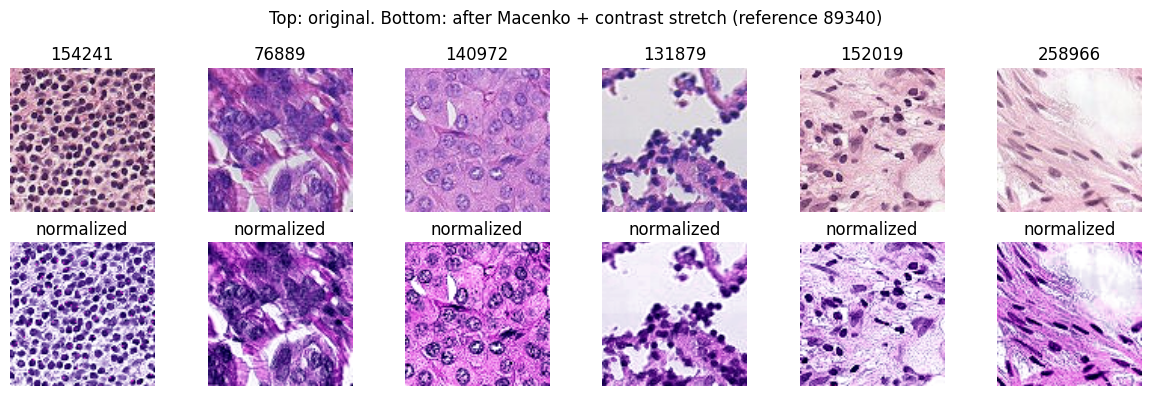

In [20]:
# Optional: apply to a few other patches and show before/after
# Why do some patches go completely purple after Macenko? The normalizer only *rebalances* the
# H and E already present. If a source patch has very little eosin (pink)—e.g. dense nuclei,
# pale staining, or mostly hematoxylin—there is almost no pink to scale up, so the result stays purple.
# Patches that look good (140972, 131879, 258966) have both stains; ones that go full purple (202357, 154241) don't.
# Luminosity standardization before transform helps keep H&E balance.
# Contrast stretch after normalization restores visible contrast (normalized images often look pale).
def contrast_stretch_uint8(img, p_low=2, p_high=98):
    """Stretch pixel values so p_low and p_high percentiles map to 0 and 255. Returns uint8."""
    lo, hi = np.percentile(img, (p_low, p_high))
    if hi <= lo:
        return img
    out = (np.clip(img.astype(np.float32), lo, hi) - lo) / (hi - lo) * 255
    return out.astype(np.uint8)
if normalizer is not None:
    n_show = 6
    other_indices = [int(candidates[i, idx_col]) for i in range(len(candidates)) if int(candidates[i, idx_col]) != ref_train_idx][:n_show]
    fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))
    for j, idx in enumerate(other_indices[:n_show]):
        p = np.asarray(train_x[idx])
        if p.max() <= 1.0: p = (np.clip(p, 0, 1) * 255).astype(np.uint8)
        else: p = np.clip(p, 0, 255).astype(np.uint8)
        axes[0, j].imshow(p, interpolation='bilinear')
        axes[0, j].set_title(str(idx))
        axes[0, j].axis("off")
        try:
            try:
                from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer
                p = LuminosityStandardizer.standardize(p.copy())
            except Exception:
                pass
            p_norm = normalizer.transform(p)
            p_norm = contrast_stretch_uint8(p_norm)
            axes[1, j].imshow(p_norm, interpolation='bilinear')
        except Exception as e:
            axes[1, j].text(0.5, 0.5, "fail", ha='center', va='center')
        axes[1, j].set_title("normalized")
        axes[1, j].axis("off")
    plt.suptitle("Top: original. Bottom: after Macenko + contrast stretch (reference " + str(ref_train_idx) + ")")
    plt.tight_layout()
    plt.show()

## 4. Macenko vs Reinhard: decision rule

**Rule:** Patches with **low blue_dom_pct** (few pixels with B &gt; R) go purple with Macenko; use **Reinhard** for those. Otherwise use **Macenko**. Threshold: below 25th percentile of blue_dom_pct in the sample → Reinhard. Same reference for both.

blue_dom_pct threshold (p25): 0.0482
Of 30000 sampled patches: 7496 -> Reinhard, 22504 -> Macenko


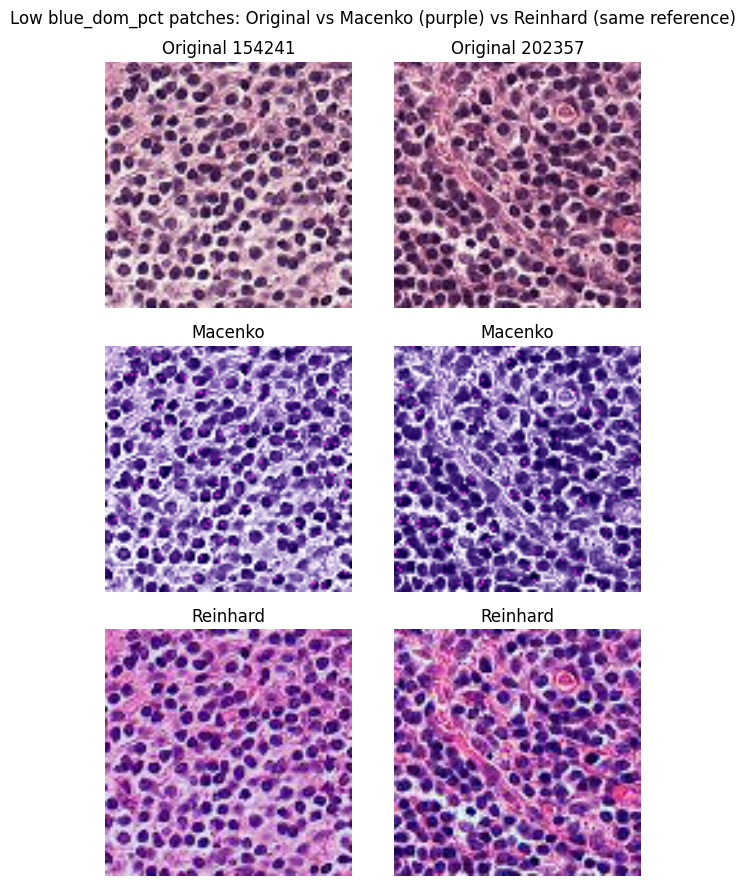

In [21]:
# Rule: blue_dom_pct < threshold -> Reinhard (else Macenko). Threshold = 25th percentile of sample.
REINHARD_PERCENTILE = 25
blue_dom_threshold = np.percentile(data[:, blue_dom_col], REINHARD_PERCENTILE)
to_reinhard = data[:, blue_dom_col] < blue_dom_threshold
n_reinhard = int(to_reinhard.sum())
n_macenko = len(data) - n_reinhard
print(f"blue_dom_pct threshold (p{REINHARD_PERCENTILE}): {blue_dom_threshold:.4f}")
print(f"Of {len(data)} sampled patches: {n_reinhard} -> Reinhard, {n_macenko} -> Macenko")

# Fit Reinhard on same reference
ref_uint8 = (np.clip(ref_patch, 0, 1) * 255).astype(np.uint8) if ref_patch.max() <= 1.0 else np.clip(ref_patch, 0, 255).astype(np.uint8)
try:
    from staintools import ReinhardColorNormalizer
    reinhard_norm = ReinhardColorNormalizer()
    reinhard_norm.fit(ref_uint8)
except Exception as e:
    print("Reinhard fit failed:", e)

# Show the two problematic patches (154241, 202357): Original / Macenko / Reinhard
bad_idx = [154241, 202357]
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for j, idx in enumerate(bad_idx):
    p = np.asarray(train_x[idx])
    p_uint8 = (np.clip(p, 0, 1) * 255).astype(np.uint8) if p.max() <= 1.0 else np.clip(p, 0, 255).astype(np.uint8)
    axes[0, j].imshow(p_uint8, interpolation='bilinear')
    axes[0, j].set_title(f"Original {idx}")
    axes[0, j].axis("off")
    try:
        p_mac = normalizer.transform(p_uint8.copy())
        axes[1, j].imshow(contrast_stretch_uint8(p_mac), interpolation='bilinear')
    except Exception:
        axes[1, j].text(0.5, 0.5, "Macenko fail", ha='center', va='center')
    axes[1, j].set_title("Macenko")
    axes[1, j].axis("off")
    try:
        p_rein = reinhard_norm.transform(p_uint8.copy())
        axes[2, j].imshow(contrast_stretch_uint8(p_rein), interpolation='bilinear')
    except Exception:
        axes[2, j].text(0.5, 0.5, "Reinhard fail", ha='center', va='center')
    axes[2, j].set_title("Reinhard")
    axes[2, j].axis("off")
plt.suptitle("Low blue_dom_pct patches: Original vs Macenko (purple) vs Reinhard (same reference)")
plt.tight_layout()
plt.show()

## 5. (Optional) How the rule was chosen

Comparing patches **154241, 202357** (go purple with Macenko) vs **140972, 131879, 258966** (work well), **blue_dom_pct** (fraction of pixels with B &gt; R) was the strongest separator: low blue_dom_pct → use Reinhard. Section 4 applies this as a percentile threshold on the sample.

In [22]:
# Decision rule from quantitative comparison: blue_dom_pct was strongest separator (low in bad patches).
print("Rule: blue_dom_pct < threshold -> Reinhard; else Macenko. Threshold and counts in Section 4.")

Rule: blue_dom_pct < threshold -> Reinhard; else Macenko. Threshold and counts in Section 4.


## 4. Save reference index for pipeline

Save the chosen train index (and options) so the preprocessing pipeline or training can use the same reference.

In [23]:
out_dir = os.path.join(PROJECT_ROOT, "experiments", "stain_reference")
os.makedirs(out_dir, exist_ok=True)

stain_ref = {
    "reference_train_index": ref_train_idx,
    "REFERENCE_MIN_TISSUE": REFERENCE_MIN_TISSUE,
    "n_candidates": len(candidates),
    "n_sample": n_sample,
}
path = os.path.join(out_dir, "stain_reference.json")
with open(path, "w") as f:
    json.dump(stain_ref, f, indent=2)
print("Saved", path)
print(json.dumps(stain_ref, indent=2))

Saved c:\GP_ECG\experiments\stain_reference\stain_reference.json
{
  "reference_train_index": 89340,
  "REFERENCE_MIN_TISSUE": 0.5,
  "n_candidates": 27376,
  "n_sample": 30000
}


In [24]:
# Bad patches (154241, 202357) Original / Macenko / Reinhard are shown in Section 4.

## 5. Compare references on test set (old 76889 vs new 89340)

We compare the **old manual reference (76889)** and the **new computed reference (89340)** on a sample of test patches (kept after quality filter). For each reference we fit Macenko and Reinhard, apply the same blue_dom decision rule, and measure: mean L1 distance to ref after norm, purple-only rate, and std(mean R/G/B). Lower distance and lower purple-only rate are better.

In [26]:
import h5py

# Reference indices to compare
REF_OLD = 76889   # old manual reference
REF_NEW = 89340   # new computed (median) reference

# Paths
PREPROC_DIR = os.path.join(DATA_DIR, "preprocessed")
MANIFEST_PATH = os.path.join(PREPROC_DIR, "manifest.json")
TEST_X_PATH = os.path.join(DATA_DIR, "test", "camelyonpatch_level_2_split_test_x.h5")
NORMALIZE_SUMMARY_PATH = os.path.join(PROJECT_ROOT, "experiments", "stain_normalize_full", "normalize_summary.json")

# Load test kept indices and blue_dom threshold
with open(MANIFEST_PATH, "r") as f:
    manifest = json.load(f)
kept_test = np.array(manifest["test"]["kept_indices"], dtype=np.int64)

preprocess_report_path = os.path.join(PREPROC_DIR, "preprocess_report.json")
if os.path.isfile(preprocess_report_path):
    with open(preprocess_report_path, "r") as f:
        rep = json.load(f)
    blue_dom_threshold = rep["config"]["blue_dom_threshold"]
    print("blue_dom_threshold from preprocess_report:", blue_dom_threshold)
elif os.path.isfile(NORMALIZE_SUMMARY_PATH):
    with open(NORMALIZE_SUMMARY_PATH, "r") as f:
        summary = json.load(f)
    blue_dom_threshold = summary["blue_dom_threshold"]
    print("blue_dom_threshold from normalize_summary:", blue_dom_threshold)
else:
    blue_dom_threshold = 0.25  # fallback
    print("blue_dom_threshold (fallback):", blue_dom_threshold)

# Sample test positions (to keep memory low)
np.random.seed(123)
n_test_sample = min(3000, len(kept_test))
sample_pos = np.random.choice(len(kept_test), size=n_test_sample, replace=False)
orig_indices = kept_test[sample_pos]

# Load test patches (original, not preprocessed). h5py requires indices in increasing order.
sort_perm = np.argsort(orig_indices)
sorted_indices = orig_indices[sort_perm]
with h5py.File(TEST_X_PATH, "r") as f:
    loaded = np.array(f["x"][sorted_indices])
test_patches = np.empty_like(loaded)
test_patches[sort_perm] = loaded  # restore original order
test_patches_01 = np.clip(test_patches.astype(np.float64) / 255.0, 0, 1) if test_patches.max() > 1 else np.clip(test_patches.astype(np.float64), 0, 1)
print("Loaded", len(test_patches_01), "test patches (shape", test_patches_01.shape, ")")

# Get reference patches from train (already in memory)
def get_ref_patch(idx):
    p = np.asarray(train_x[idx]).astype(np.float64)
    if p.max() > 1.0:
        p = p / 255.0
    return np.clip(p, 0, 1)

ref_old_01 = get_ref_patch(REF_OLD)
ref_new_01 = get_ref_patch(REF_NEW)
ref_old_u8 = (ref_old_01 * 255).astype(np.uint8)
ref_new_u8 = (ref_new_01 * 255).astype(np.uint8)

blue_dom_threshold from preprocess_report: 0.04861111111111111
Loaded 3000 test patches (shape (3000, 96, 96, 3) )


In [27]:
from staintools import StainNormalizer, ReinhardColorNormalizer
from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer

def fit_normalizers_for_ref(ref_01, ref_u8):
    lum_std = LuminosityStandardizer()
    ref_fit = lum_std.standardize(ref_u8.copy())
    macenko = StainNormalizer(method="macenko")
    macenko.fit(ref_fit)
    reinhard = ReinhardColorNormalizer()
    reinhard.fit(ref_u8)
    ref_mean_rgb = (float(ref_01[:,:,0].mean()), float(ref_01[:,:,1].mean()), float(ref_01[:,:,2].mean()))
    return macenko, reinhard, lum_std, ref_mean_rgb

def normalize_one(patch_01, macenko, reinhard, lum_std, blue_dom_threshold):
    bd = (patch_01[:,:,2] > patch_01[:,:,0]).mean()
    use_reinhard = bd < blue_dom_threshold
    pu8 = (np.clip(patch_01, 0, 1) * 255).astype(np.uint8)
    try:
        pstd = lum_std.standardize(pu8)
    except Exception:
        pstd = pu8
    try:
        norm_u8 = reinhard.transform(pstd) if use_reinhard else macenko.transform(pstd)
    except Exception:
        try:
            norm_u8 = macenko.transform(pstd) if use_reinhard else reinhard.transform(pstd)
        except Exception:
            norm_u8 = pstd
    return np.clip(norm_u8.astype(np.float64) / 255.0, 0, 1)

# Fit both references
macenko_old, reinhard_old, lum_old, mean_rgb_old = fit_normalizers_for_ref(ref_old_01, ref_old_u8)
macenko_new, reinhard_new, lum_new, mean_rgb_new = fit_normalizers_for_ref(ref_new_01, ref_new_u8)
print("Ref 76889 mean RGB:", [round(x, 4) for x in mean_rgb_old])
print("Ref 89340 mean RGB:", [round(x, 4) for x in mean_rgb_new])

Ref 76889 mean RGB: [0.6137, 0.3966, 0.6954]
Ref 89340 mean RGB: [0.67, 0.4748, 0.7059]


In [28]:
# Normalize test sample with both references and compute metrics
def run_metrics(patches_01, macenko, reinhard, lum_std, ref_mean_rgb, blue_dom_threshold):
    mean_dists = []
    mean_r_list = []
    mean_g_list = []
    mean_b_list = []
    purple_only_count = 0
    norm_list = []
    for i in range(patches_01.shape[0]):
        norm = normalize_one(patches_01[i], macenko, reinhard, lum_std, blue_dom_threshold)
        norm_list.append(norm)
        m = (norm[:,:,0].mean(), norm[:,:,1].mean(), norm[:,:,2].mean())
        mean_r_list.append(m[0]); mean_g_list.append(m[1]); mean_b_list.append(m[2])
        d = sum(abs(a - b) for a, b in zip(m, ref_mean_rgb))
        mean_dists.append(d)
        pink_pct = (norm[:,:,0] > norm[:,:,2]).mean()
        if m[0] < 0.2 or pink_pct < 0.05:
            purple_only_count += 1
    mean_dists = np.array(mean_dists)
    return {
        "mean_l1_dist": float(mean_dists.mean()),
        "std_mean_r": float(np.std(mean_r_list)),
        "std_mean_g": float(np.std(mean_g_list)),
        "std_mean_b": float(np.std(mean_b_list)),
        "purple_only_count": purple_only_count,
        "purple_only_pct": 100.0 * purple_only_count / len(patches_01),
        "norm_list": norm_list,
    }

print("Normalizing test sample with ref 76889 ...")
metrics_old = run_metrics(test_patches_01, macenko_old, reinhard_old, lum_old, mean_rgb_old, blue_dom_threshold)
print("Normalizing test sample with ref 89340 ...")
metrics_new = run_metrics(test_patches_01, macenko_new, reinhard_new, lum_new, mean_rgb_new, blue_dom_threshold)

Normalizing test sample with ref 76889 ...
Normalizing test sample with ref 89340 ...


In [29]:
# Comparison table
print("=" * 60)
print("Test set comparison (n = {} patches)".format(n_test_sample))
print("=" * 60)
print("{:30} {:>12} {:>12}".format("Metric", "Ref 76889", "Ref 89340"))
print("-" * 60)
print("{:30} {:>12.4f} {:>12.4f}".format("Mean L1 dist to ref (lower better)", metrics_old["mean_l1_dist"], metrics_new["mean_l1_dist"]))
print("{:30} {:>12.2f}% {:>12.2f}%".format("Purple-only rate (lower better)", metrics_old["purple_only_pct"], metrics_new["purple_only_pct"]))
print("{:30} {:>12.4f} {:>12.4f}".format("Std(mean R) after norm", metrics_old["std_mean_r"], metrics_new["std_mean_r"]))
print("{:30} {:>12.4f} {:>12.4f}".format("Std(mean G) after norm", metrics_old["std_mean_g"], metrics_new["std_mean_g"]))
print("{:30} {:>12.4f} {:>12.4f}".format("Std(mean B) after norm", metrics_old["std_mean_b"], metrics_new["std_mean_b"]))
print("=" * 60)

better_dist = "89340" if metrics_new["mean_l1_dist"] < metrics_old["mean_l1_dist"] else "76889"
better_purple = "89340" if metrics_new["purple_only_pct"] < metrics_old["purple_only_pct"] else "76889"
print("Lower mean L1 dist: ref {}  |  Fewer purple-only: ref {}".format(better_dist, better_purple))

Test set comparison (n = 3000 patches)
Metric                            Ref 76889    Ref 89340
------------------------------------------------------------
Mean L1 dist to ref (lower better)       0.3791       0.2337
Purple-only rate (lower better)         1.77%        18.13%
Std(mean R) after norm               0.0874       0.0818
Std(mean G) after norm               0.1235       0.1122
Std(mean B) after norm               0.0635       0.0637
Lower mean L1 dist: ref 89340  |  Fewer purple-only: ref 76889


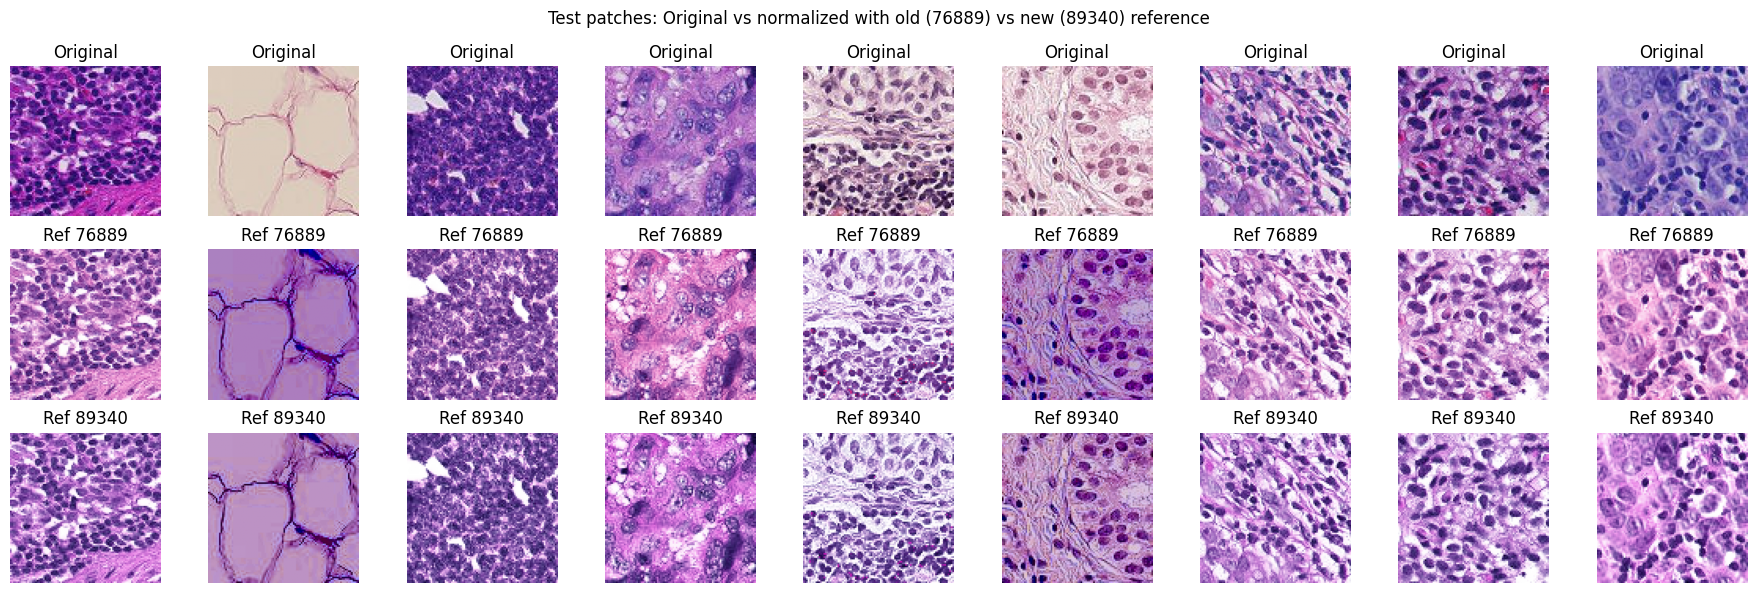

In [30]:
# Visual: same test patches — Original | Norm ref 76889 | Norm ref 89340
n_show = 9
fig, axes = plt.subplots(3, n_show, figsize=(2 * n_show, 6))
for j in range(n_show):
    axes[0, j].imshow(test_patches_01[j])
    axes[0, j].set_title("Original")
    axes[0, j].axis("off")
    axes[1, j].imshow(metrics_old["norm_list"][j])
    axes[1, j].set_title("Ref 76889")
    axes[1, j].axis("off")
    axes[2, j].imshow(metrics_new["norm_list"][j])
    axes[2, j].set_title("Ref 89340")
    axes[2, j].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Ref 76889", fontsize=11)
axes[2, 0].set_ylabel("Ref 89340", fontsize=11)
plt.suptitle("Test patches: Original vs normalized with old (76889) vs new (89340) reference", fontsize=12)
plt.tight_layout()
plt.show()